<a href="https://colab.research.google.com/github/kej534923-maker/ECON5200-Applied-Data-Analytics/blob/main/Econ_5200_Assignment_3_Causal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

Step 1.1: The Zero-Inflated Gig Economy Tip Distribution

In [7]:
np.random.seed(42)

# 100 drivers tipped exactly $0
zeros = np.zeros(100)

# 150 tips drawn from an exponential distribution (right-skewed)
tips = np.random.exponential(scale=5.0, size=150)

driver_tips = np.concatenate([zeros, tips])

print("Total observations:", len(driver_tips))
print("Number of zero tips:", np.sum(driver_tips == 0))
print("Mean tip:", np.mean(driver_tips))
print("Median tip:", np.median(driver_tips))
print(driver_tips[:10])

Total observations: 250
Number of zero tips: 100
Mean tip: 2.7690587934081927
Median tip: 0.7553316913699188
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Step 1.2: Manual Bootstrap Engine

In [8]:
B = 10000
n = len(driver_tips)
bootstrap_medians = np.empty(B)

# Manual bootstrap loop
for b in range(B):
    sample_b = np.random.choice(driver_tips, size=n, replace=True)
    bootstrap_medians[b] = np.median(sample_b)

# 95% bootstrap confidence interval using percentiles
ci_lower, ci_upper = np.percentile(bootstrap_medians, [2.5, 97.5])

print("Original sample median:", np.median(driver_tips))
print("Bootstrap 95% CI for the median:", (ci_lower, ci_upper))

print("Bootstrap mean of medians:", np.mean(bootstrap_medians))
print("Bootstrap std of medians:", np.std(bootstrap_medians, ddof=1))

Original sample median: 0.7553316913699188
Bootstrap 95% CI for the median: (np.float64(0.2653018357387816), np.float64(1.3635639228066991))
Bootstrap mean of medians: 0.7667362220195687
Bootstrap std of medians: 0.2771066081438598


Step 2.1: Algorithmic Routing Crash A/B Test

In [9]:
import numpy as np
np.random.seed(42)
n_control = 500
n_treatment = 500
control_times = np.random.normal(loc=35, scale=5, size=n_control)
treatment_times = np.random.lognormal(mean=3.4, sigma=0.4, size=n_treatment)

# Compute group means
control_mean = np.mean(control_times)
treatment_mean = np.mean(treatment_times)

observed_diff = control_mean - treatment_mean

print("Control mean delivery time:", control_mean)
print("Treatment mean delivery time:", treatment_mean)
print("Observed difference (Control - Treatment):", observed_diff)

Control mean delivery time: 35.03418997294323
Treatment mean delivery time: 32.76920784231749
Observed difference (Control - Treatment): 2.2649821306257394


Step 2.2: Manual Permutation Test

Observed difference in means (Control - Treatment): 2.2649821306257394
Number of extreme permutations: 2
Empirical permutation p-value: 0.0004


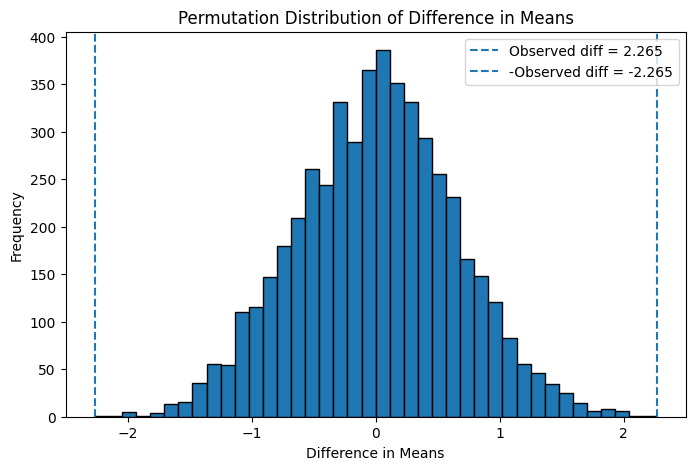

In [10]:
all_times = np.concatenate([control_times, treatment_times])
observed_diff = np.mean(control_times) - np.mean(treatment_times)

B = 5000
perm_diffs = np.empty(B)

for b in range(B):
    shuffled = np.random.permutation(all_times)
    pseudo_control = shuffled[:500]
    pseudo_treatment = shuffled[500:]
    perm_diffs[b] = np.mean(pseudo_control) - np.mean(pseudo_treatment)

count_extreme = np.sum(np.abs(perm_diffs) >= np.abs(observed_diff))
p_value = count_extreme / B

print("Observed difference in means (Control - Treatment):", observed_diff)
print("Number of extreme permutations:", count_extreme)
print("Empirical permutation p-value:", p_value)

plt.figure(figsize=(8, 5))
plt.hist(perm_diffs, bins=40, edgecolor='black')
plt.axvline(observed_diff, linestyle='--', label=f'Observed diff = {observed_diff:.3f}')
plt.axvline(-observed_diff, linestyle='--', label=f'-Observed diff = {-observed_diff:.3f}')
plt.title("Permutation Distribution of Difference in Means")
plt.xlabel("Difference in Means")
plt.ylabel("Frequency")
plt.legend()
plt.show()

Step 3.1: Loyalty Program Paradox

In [13]:
import pandas as pd
import numpy as np

df = pd.read_csv("swiftcart_loyalty.csv")

means = df.groupby("subscriber")["post_spend"].mean()

mean_non = means[0]
mean_sub = means[1]

# Naive SDO
sdo = mean_sub - mean_non

print("Mean post-spending (Subscribers):", mean_sub)
print("Mean post-spending (Non-Subscribers):", mean_non)
print("Naive Simple Difference in Outcomes (SDO):", sdo)

Mean post-spending (Subscribers): 74.04358604052543
Mean post-spending (Non-Subscribers): 56.47291665600162
Naive Simple Difference in Outcomes (SDO): 17.570669384523804


Step 3.2: Propensity Score Matching (PSM) Architecture

In [15]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

df = pd.read_csv("swiftcart_loyalty.csv")

D = df["subscriber"]
X = df[["pre_spend", "account_age", "support_tickets"]]

logit = LogisticRegression(max_iter=1000)
logit.fit(X, D)

df["propensity_score"] = logit.predict_proba(X)[:, 1]

treated = df[df["subscriber"] == 1].copy()
control = df[df["subscriber"] == 0].copy()

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[["propensity_score"]])

distances, indices = nn.kneighbors(treated[["propensity_score"]])

matched_controls = control.iloc[indices.flatten()].copy()

treated = treated.reset_index(drop=True)
matched_controls = matched_controls.reset_index(drop=True)

att = np.mean(treated["post_spend"] - matched_controls["post_spend"])

print("Number of treated users:", len(treated))
print("Number of matched control users:", len(matched_controls))
print("Average Treatment Effect on the Treated (ATT):", att)

naive_sdo = df[df["subscriber"] == 1]["post_spend"].mean() - df[df["subscriber"] == 0]["post_spend"].mean()

print("Naive Simple Difference in Outcomes (SDO):", naive_sdo)
print("ATT - Naive SDO difference:", att - naive_sdo)

Number of treated users: 4200
Number of matched control users: 4200
Average Treatment Effect on the Treated (ATT): 9.913855182824864
Naive Simple Difference in Outcomes (SDO): 17.57066938452379
ATT - Naive SDO difference: -7.656814201698925


Task 4.1: The "Love Plot" Visualization Directive

In [17]:
df_matched = pd.concat([treated, matched_controls], ignore_index=True)
df_unmatched = df.copy()

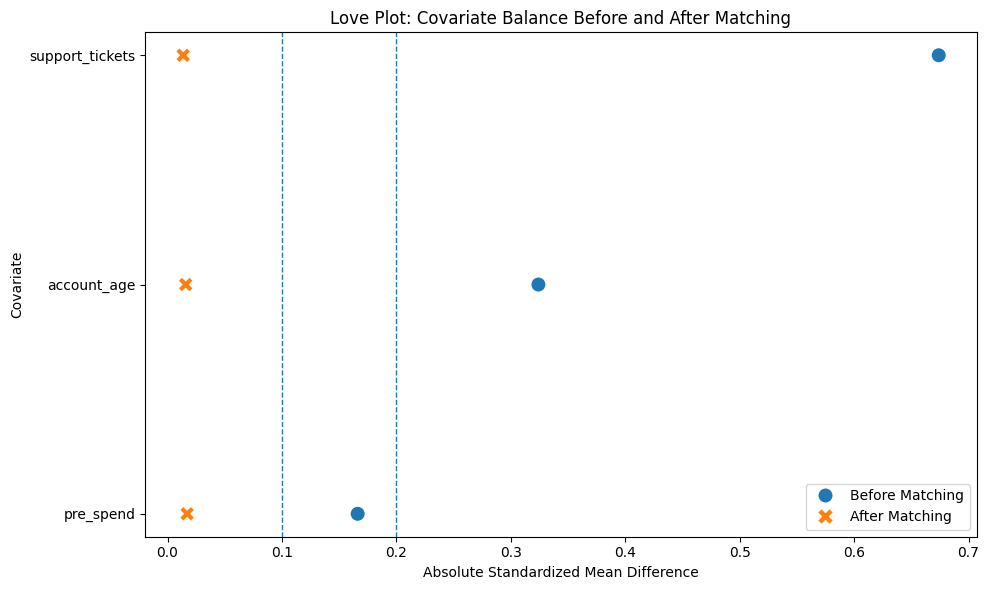

Standardized Mean Differences Before Matching:
         Covariate       SMD           Sample
0        pre_spend  0.673959  Before Matching
1      account_age  0.324109  Before Matching
2  support_tickets -0.166146  Before Matching

Standardized Mean Differences After Matching:
         Covariate       SMD          Sample
0  support_tickets  0.017112  After Matching
1      account_age -0.015871  After Matching
2        pre_spend  0.013664  After Matching


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def compute_smd(df, treatment_col, covariates):
    smd_list = []
    treated = df[df[treatment_col] == 1]
    control = df[df[treatment_col] == 0]

    for var in covariates:
        mean_t = treated[var].mean()
        mean_c = control[var].mean()
        var_t = treated[var].var(ddof=1)
        var_c = control[var].var(ddof=1)
        pooled_sd = np.sqrt((var_t + var_c) / 2)

        if pooled_sd == 0:
            smd = 0
        else:
            smd = (mean_t - mean_c) / pooled_sd

        smd_list.append({
            "Covariate": var,
            "SMD": smd
        })

    return pd.DataFrame(smd_list)

treatment_col = "subscriber"
covariates = [col for col in df_unmatched.columns if col not in [treatment_col, "post_spend", "propensity_score"]]

smd_before = compute_smd(df_unmatched, treatment_col, covariates)
smd_before["Sample"] = "Before Matching"

smd_after = compute_smd(df_matched, treatment_col, covariates)
smd_after["Sample"] = "After Matching"

love_plot_df = pd.concat([smd_before, smd_after], ignore_index=True)
love_plot_df["abs_SMD"] = love_plot_df["SMD"].abs()

order = (
    love_plot_df[love_plot_df["Sample"] == "Before Matching"]
    .sort_values("abs_SMD", ascending=True)["Covariate"]
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=love_plot_df,
    x="abs_SMD",
    y="Covariate",
    hue="Sample",
    style="Sample",
    s=120
)

for threshold in [0.1, 0.2]:
    plt.axvline(threshold, linestyle="--", linewidth=1)

plt.xlabel("Absolute Standardized Mean Difference")
plt.ylabel("Covariate")
plt.title("Love Plot: Covariate Balance Before and After Matching")
plt.yticks(ticks=range(len(order)), labels=order)
plt.legend(title="")
plt.tight_layout()
plt.show()

print("Standardized Mean Differences Before Matching:")
print(smd_before.sort_values("SMD", key=np.abs, ascending=False).reset_index(drop=True))

print("\nStandardized Mean Differences After Matching:")
print(smd_after.sort_values("SMD", key=np.abs, ascending=False).reset_index(drop=True))